# Predicting and Understanding Project Approval Outcomes on a Nonprofit Platform Using DonorsChoose Data


# Business Context
Nonprofit crowdfunding platforms rely on structured project submissions to connect mission-driven initiatives with potential donors. Before campaigns can generate donations, platforms must evaluate and approve submitted projects to ensure quality, legitimacy, and alignment with platform guidelines.

Project approval therefore represents a critical conversion event in the platform lifecycle. Approved projects gain visibility, while unapproved projects never reach potential donors.

Understanding the drivers of project approval is essential for:
- Improving submission quality
- Enhancing platform efficiency
- Supporting teachers and project creators
- Optimizing platform growth dynamics


# Business Problem 
Despite standardized submission processes, not all projects submitted to nonprofit platforms are approved. Variability in approval outcomes may arise from differences in:
- Project cost structures
- Submission characteristics
- Teacher experience
- Project categories
- Textual descriptions

The core business problem addressed in this project is:

#### What factors influence whether a submitted project is approved, and how can those insights improve platform decision-making?


# Data Science Problem Framing
This problem is framed as a binary classification task:
- **Target Variable:** project_is_approved
- **Prediction Goal:** Estimate likelihood of project approval

Supporting analytics include:
- **Descriptive Analysis:** Identify patterns in approved vs unapproved projects
- **Predictive Modeling:** Build models that predict approval outcomes
- **Prescriptive Insights:** Recommend actions to improve approval likelihood


# Project Objectives
The primary objectives of this project are to:
1. Analyze historical project submission data
2. Identify features associated with approval outcomes
3. Quantify relationships between cost, experience, category, and text variables
4. Build a predictive approval model
5. Generate actionable platform-level recommendations

# Impact on Stakeholders
The insights from the analysis from this project are valuable to multiple stakeholders:
#### Platform Analytics Teams
- Improve approval workflows
- Detect low-quality submissions
- Optimize platform efficiency
  
#### Campaign Creators
- Understand characteristics of successful submissions
- Improve proposal quality

#### Growth and Strategy Teams
- Align approval policies with platform objectives

# Key Business Metrics (KPIs)
To evaluate campaign performance and platform effectiveness, this project focuses on the following key metrics:
- **Approval Rate** - Percentage of project approved
- **Prediction Accuracy** - Model performance
- **False Positive / Negative Rates** - Decision quality
- **Cost vs Approval Relationship** 
- **Text Quality Signals**

# Data Source
The data used in this project is from DonorsChoose, a crowdfunding platform that enables teachers to raise funds for classroom projects. The data was obtained from a publicly available Kaggle dataset, which contains anonymized, preprocessed project-level submission attributes and approval outcomes. 

# Dataset Overview
The dataset consists of project-level observations, where each row represents a submitted classroom project.

Included variables:
- Teacher attributes
- Project categories
- Cost variables (price, quantity)
- Preprocessed text fields
- Approval outcome (project_is_approved)

# Unit of Analysis
The unit of analysis for this project is an individual project submission.

Each submission includes:
- Teacher characteristics
- Project category attributes
- Cost-related variables
- Textual descriptions
- Approval outcome


# Data Scope and Coverage
Included:
- Project submission attributes
- Teacher experience metrics
- Cost variables
- Preprocessed text fields
- Approval outcomes

Not Included:
- Donation totals
- Funding goals
- Donor counts
- User behavior / web analytics
- Marketing attribution

# Initial Data Assumptions
Before analysis, the following data assumptions are made:
1. Each row represents a unique project submission
2. Approval labels accurately reflect platform decisions
3. Cost variables represent requested resources
4. Preprocessed text fields are valid representations of proposals
5. Approval outcome can serve as a proxy for submission success

# Cleaning and Preparing the Data

In [55]:
# Loading the Dataset

import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("/Users/guestuser1/Data_Science_Projects/Preprocessed_DonorsChoose_dataset.csv")

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Shape:", df.shape)
df.head()

Shape: (109248, 14)


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


In [56]:
# Confirming Dataset Shape & Columns

print("Dataset Shape:", df.shape)
df.columns

Dataset Shape: (109248, 14)


Index(['id', 'teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'price', 'quantity', 'cleaned_titles', 'cleaned_essays',
       'cleaned_summary', 'isdigit_summary'],
      dtype='object')

In [57]:
# Quick schema check

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [58]:
# Checking for missing values

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

cleaned_titles    43
dtype: int64

#### Because missing values represent less than 0.05% (43/109000) of observations and the variable is analytically meaningful, rows with missing titles will be removed to preserve data integrity and avoid introducing artificial text patterns.

In [59]:
# Removing missing values

df = df.dropna(subset=["cleaned_titles"])

In [60]:
# Verifying to make sure missing values have been replaced/removed

df["cleaned_titles"].isna().sum()

np.int64(0)

In [61]:
# Checking for duplicate records

print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate IDs:", df.duplicated(subset=["id"]).sum())

Duplicate Rows: 0
Duplicate IDs: 0


In [62]:
# Price validation

df["price"].describe()

count    109205.000000
mean        298.126701
std         367.518882
min           0.660000
25%         104.330000
50%         206.220000
75%         379.000000
max        9999.000000
Name: price, dtype: float64

In [63]:
# Quantity validation

df["quantity"].describe()

count    109205.000000
mean         16.965450
std          26.186492
min           1.000000
25%           4.000000
50%           9.000000
75%          21.000000
max         930.000000
Name: quantity, dtype: float64

In [64]:
# Teacher experience validation

df["teacher_number_of_previously_posted_projects"].describe()

count    109205.000000
mean         11.151815
std          27.773733
min           0.000000
25%           0.000000
50%           2.000000
75%           9.000000
max         451.000000
Name: teacher_number_of_previously_posted_projects, dtype: float64

#### Business-rule validation was performed to ensure numeric features adhered to real-world constraints. Checked to make sure observations did not contain logically impossible values (e.g., negative price, non-positive quantity, negative teacher experience), as these represent data errors rather than valid extreme cases.

In [65]:
# Cost features

df["total_cost"] = df["price"] * df["quantity"]

In [66]:
# Log transforms to improve linear models

df["log_total_cost"] = np.log1p(df["total_cost"])
df["log_price"] = np.log1p(df["price"])
df["log_quantity"] = np.log1p(df["quantity"])

In [67]:
# Teacher experience features

df["is_new_teacher"] = (
    df["teacher_number_of_previously_posted_projects"] == 0
).astype(int)

In [68]:
# Bucket experience

df["teacher_experience_bucket"] = pd.cut(
    df["teacher_number_of_previously_posted_projects"],
    bins=[-1, 0, 1, 5, 10, 100000],
    labels=["0", "1", "2-5", "6-10", "10+"]
)

In [69]:
# Text length features

df["title_length"] = df["cleaned_titles"].astype(str).str.len()
df["essay_length"] = df["cleaned_essays"].astype(str).str.len()
df["summary_length"] = df["cleaned_summary"].astype(str).str.len()

In [70]:
# Word counts

df["title_word_count"] = df["cleaned_titles"].astype(str).str.split().str.len()
df["essay_word_count"] = df["cleaned_essays"].astype(str).str.split().str.len()
df["summary_word_count"] = df["cleaned_summary"].astype(str).str.split().str.len()

In [71]:
# Categorical cleanup
# This makes grouping and modeling more consistent

cat_cols = [
    "teacher_prefix",
    "school_state",
    "project_grade_category",
    "project_subject_categories",
    "project_subject_subcategories",
]

for c in cat_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

#### Feature engineering was performed to transform raw attributes into analytically meaningful signals. Cost variables were combined to capture overall project magnitude. Log transformations were applied to mitigate skewness, teacher experience features were structured to reflect behavioral tiers, and text-based metrics were created to quantify proposal richness and quality proxies.

In [72]:
# Validating target variable

df["project_is_approved"].value_counts()

project_is_approved
1    92680
0    16525
Name: count, dtype: int64

In [73]:
# Ensuring binary

df = df[df["project_is_approved"].isin([0, 1])]

In [74]:
print("Final shape:", df.shape)
display(df.head())

# Final missing check
display(df.isna().sum().sort_values(ascending=False).head(10))

Final shape: (109205, 26)


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,...,log_price,log_quantity,is_new_teacher,teacher_experience_bucket,title_length,essay_length,summary_length,title_word_count,essay_word_count,summary_word_count
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,...,5.047289,3.178054,1,0,41,1068,74,5,148,1
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,...,5.703782,0.693147,0,6-10,32,761,57,4,98,1
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,...,6.249686,3.135494,0,1,47,1385,110,6,187,1
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,...,5.454894,1.609438,0,2-5,22,825,56,2,111,1
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,...,4.233817,1.609438,0,1,22,764,107,3,111,1


id                           0
teacher_prefix               0
essay_word_count             0
title_word_count             0
summary_length               0
essay_length                 0
title_length                 0
teacher_experience_bucket    0
is_new_teacher               0
log_quantity                 0
dtype: int64

In [75]:
# Saving a cleaned version

OUTPUT_PATH = Path("/Users/guestuser1/Data_Science_Projects/processed_donorschoose.csv")
df.to_csv(OUTPUT_PATH, index=False)
print("Saved cleaned dataset to:", OUTPUT_PATH)

Saved cleaned dataset to: /Users/guestuser1/Data_Science_Projects/processed_donorschoose.csv


# Exploratory Data Analysis (EDA)

#### Pandas and numpy were installed earlier for data cleaning and analysis. Matplotplib will be installed for visualization to assist with the EDA process.

In [76]:
import matplotlib.pyplot as plt


In [77]:
target_counts = df["project_is_approved"].value_counts().sort_index()
target_rate = df["project_is_approved"].mean()

target_counts, target_rate

(project_is_approved
 0    16525
 1    92680
 Name: count, dtype: int64,
 np.float64(0.8486790897852663))

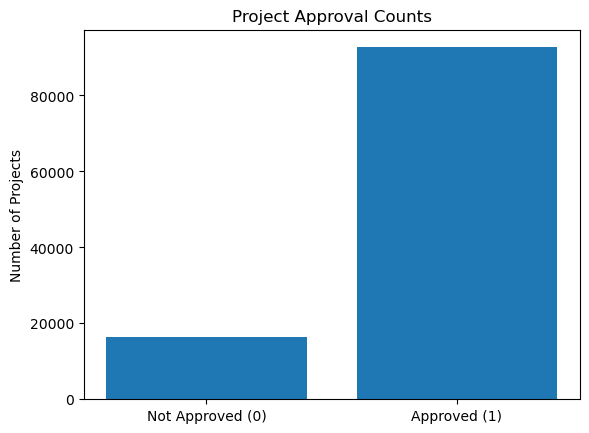

In [78]:
plt.bar(["Not Approved (0)", "Approved (1)"], target_counts.values)
plt.title("Project Approval Counts")
plt.ylabel("Number of Projects")
plt.show()

In [79]:
numeric_cols = [
    "price", "quantity", "total_cost",
    "teacher_number_of_previously_posted_projects",
    "title_length", "essay_length", "summary_length",
    "title_word_count", "essay_word_count", "summary_word_count"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,109205.0,298.126701,367.518882,0.66,104.33,206.22,379.0,9999.00
quantity,109205.0,16.965450,26.186492,1.00,4.00,9.00,21.0,930.00
total_cost,109205.0,4269.875266,12220.385602,100.00,525.00,1369.60,3753.6,954086.07
teacher_number_of_previously_posted_projects,109205.0,11.151815,27.773733,0.00,0.00,2.00,9.0,451.00
title_length,109205.0,25.687331,11.717778,1.00,17.00,24.00,33.0,93.00
essay_length,109205.0,1007.065730,276.222610,450.00,800.00,940.00,1155.0,2596.00
summary_length,109205.0,90.778115,34.677792,18.00,63.00,83.00,114.0,764.00
title_word_count,109205.0,3.696287,1.524238,1.00,3.00,3.00,5.0,15.00
essay_word_count,109205.0,137.187675,36.313999,69.00,109.00,128.00,157.0,319.00
summary_word_count,109205.0,1.000000,0.000000,1.00,1.00,1.00,1.0,1.00


#### Interpretation of Summary Statistics
- **Price:** Most requested items are moderatley priced with a few being very high. This creates a long-tailed distribution.
- **Quantity:** Most projects reqeust relatively small quantities, while a few projects involves large scale resource requests.
- **Total Cost:** Most project costs are moderate, but a small number of very expensive projects inflates the average.
- **Teacher Experience:** Teacher experience is highly skewed. Most teachers have little piror submission history, while a small subset has extensive platform experience.
- **Title:** Project titles are short and relatively standardized.
- **Essay:** Essays are fairly consistent, which suggests that the submission formats may be structured.

Exploratory analysis revealed strong right-skewness across financial variables with median project costs substantially lower than mean values, which indicates the presence of high-cost outliers. Teacher experience also exhibited heavy skew, with many new users and a smaller subset of highly experienced contributors. Text features displayed relative consistency, suggesting structured submission formats. Additionally, summary word count uniformity indicates prior preprocessing transformations.

In [80]:
# Comparing approved vs. not approved

group_means = df.groupby("project_is_approved")[numeric_cols].mean().T
group_means.columns = ["Not Approved (0)", "Approved (1)"]
group_means["Difference (1 - 0)"] = group_means["Approved (1)"] - group_means["Not Approved (0)"]
group_means.sort_values("Difference (1 - 0)", ascending=False).head(15)

,Not Approved (0),Approved (1),Difference (1 - 0)
essay_length,961.889259,1015.120770,53.231512
essay_word_count,130.448714,138.389243,7.940528
teacher_number_of_previously_posted_projects,6.889682,11.911761,5.022079
title_length,25.613616,25.700475,0.086859
title_word_count,3.661664,3.702460,0.040796
summary_word_count,1.000000,1.000000,0.000000
quantity,20.198487,16.388994,-3.809493
summary_length,94.162542,90.174666,-3.987876
price,359.857218,287.120046,-72.737171
total_cost,7035.010854,3776.846936,-3258.163919


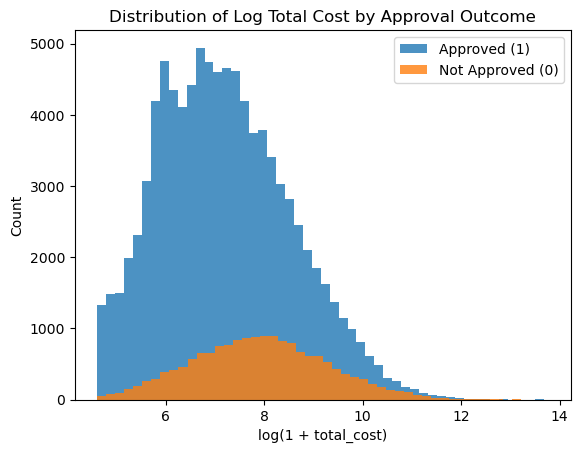

In [81]:
# Total cost vs. approval (using engineered log feature)

approved = df[df["project_is_approved"] == 1]["log_total_cost"]
not_approved = df[df["project_is_approved"] == 0]["log_total_cost"]

plt.hist(approved, bins=50, alpha=0.8, label="Approved (1)")
plt.hist(not_approved, bins=50, alpha=0.8, label="Not Approved (0)")
plt.title("Distribution of Log Total Cost by Approval Outcome")
plt.xlabel("log(1 + total_cost)")
plt.ylabel("Count")
plt.legend()
plt.show()

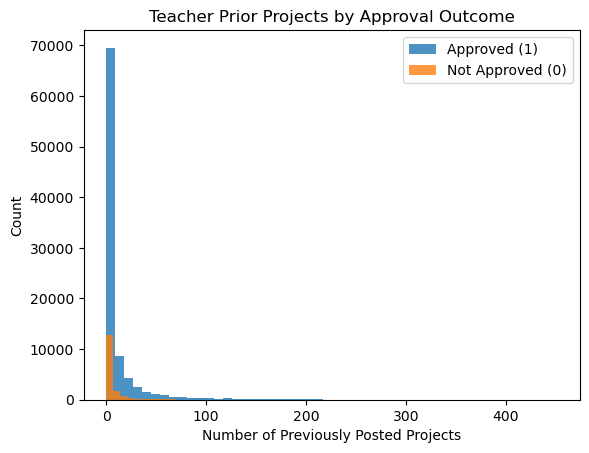

In [82]:
# Teacher experience vs. approval

plt.hist(df[df["project_is_approved"] == 1]["teacher_number_of_previously_posted_projects"], bins=50, alpha=0.8, label="Approved (1)")
plt.hist(df[df["project_is_approved"] == 0]["teacher_number_of_previously_posted_projects"], bins=50, alpha=0.8, label="Not Approved (0)")
plt.title("Teacher Prior Projects by Approval Outcome")
plt.xlabel("Number of Previously Posted Projects")
plt.ylabel("Count")
plt.legend()
plt.show()

In [83]:
# Approval by state

approval_by_state = df.groupby("school_state")["project_is_approved"].mean().sort_values(ascending=False)

approval_by_state.head(10), approval_by_state.tail(10)

(school_state
 de    0.900585
 nd    0.888112
 wa    0.876178
 oh    0.875507
 nh    0.873563
 ct    0.868912
 ky    0.863497
 ma    0.860553
 sc    0.860193
 nm    0.859964
 Name: project_is_approved, dtype: float64,
 school_state
 ut    0.836511
 id    0.835498
 ok    0.834725
 fl    0.831797
 ar    0.831268
 la    0.831245
 mt    0.816327
 tx    0.813447
 dc    0.802326
 vt    0.800000
 Name: project_is_approved, dtype: float64)

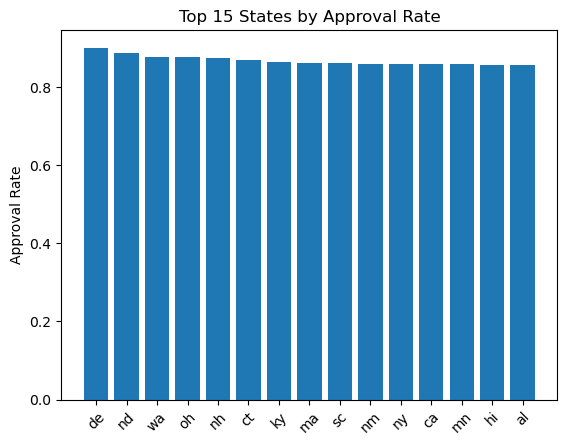

In [84]:
# Approval by top 15 states

top_states = approval_by_state.head(15)
plt.bar(top_states.index, top_states.values)
plt.title("Top 15 States by Approval Rate")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45)
plt.show()

In [85]:
# Approval by project_grade_category

approval_by_grade = df.groupby("project_grade_category")["project_is_approved"].mean().sort_values(ascending=False)
approval_by_grade

project_grade_category
grades_3_5       0.854426
grades_prek_2    0.848896
grades_6_8       0.842616
grades_9_12      0.837697
Name: project_is_approved, dtype: float64

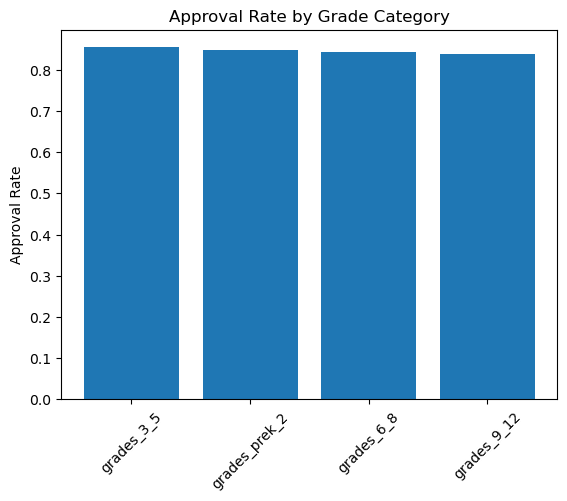

In [86]:
plt.bar(approval_by_grade.index, approval_by_grade.values)
plt.title("Approval Rate by Grade Category")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45)
plt.show()

In [87]:
# Approval by project_subject_categories

approval_by_subject = df.groupby("project_subject_categories")["project_is_approved"].mean().sort_values(ascending=False)
approval_by_subject.head(15)

project_subject_categories
health_sports_warmth_care_hunger     0.956522
warmth_care_hunger                   0.925898
history_civics_health_sports         0.923077
history_civics_literacy_language     0.894217
health_sports_history_civics         0.883721
literacy_language_history_civics     0.877627
music_arts_specialneeds              0.876812
health_sports_specialneeds           0.873472
literacy_language_math_science       0.869515
literacy_language                    0.867631
appliedlearning_literacy_language    0.861644
math_science_literacy_language       0.859764
math_science_history_civics          0.857143
history_civics_math_science          0.857143
literacy_language_specialneeds       0.855951
Name: project_is_approved, dtype: float64

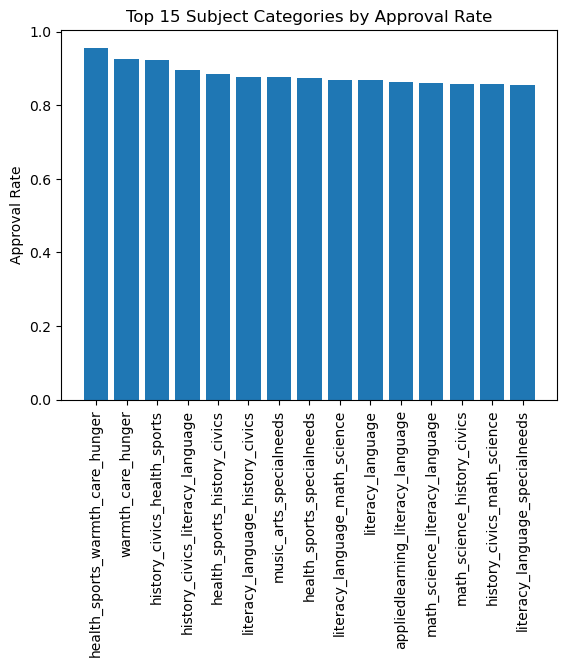

In [88]:
top_subjects = approval_by_subject.head(15)
plt.bar(top_subjects.index, top_subjects.values)
plt.title("Top 15 Subject Categories by Approval Rate")
plt.ylabel("Approval Rate")
plt.xticks(rotation=90)
plt.show()

In [89]:
# Essay length vs. approval
# Doess proposal text richness matter?

df.groupby("project_is_approved")[["essay_length", "essay_word_count"]].mean()

,essay_length,essay_word_count
project_is_approved,,
0,961.889259,130.448714
1,1015.120770,138.389243


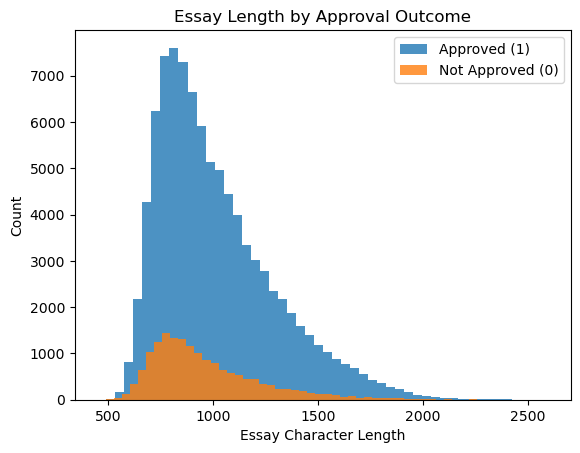

In [90]:
plt.hist(df[df["project_is_approved"] == 1]["essay_length"], bins=50, alpha=0.8, label="Approved (1)")
plt.hist(df[df["project_is_approved"] == 0]["essay_length"], bins=50, alpha=0.8, label="Not Approved (0)")
plt.title("Essay Length by Approval Outcome")
plt.xlabel("Essay Character Length")
plt.ylabel("Count")
plt.legend()
plt.show()

In [91]:
# Approval rate when summary is numeric only (isdigit_summary column)

df.groupby("isdigit_summary")["project_is_approved"].mean()

isdigit_summary
0    0.840972
1    0.894413
Name: project_is_approved, dtype: float64

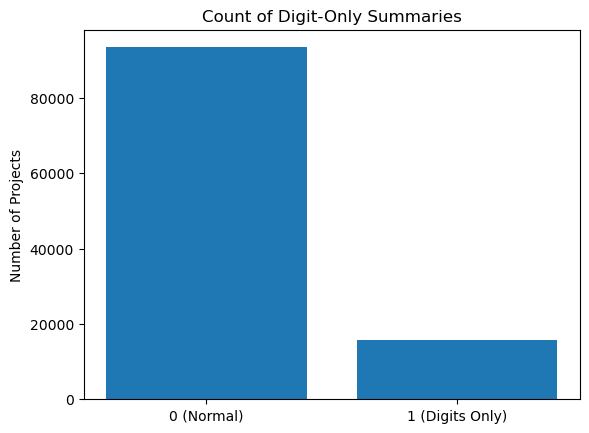

In [92]:
counts = df["isdigit_summary"].value_counts().sort_index()
plt.bar(["0 (Normal)", "1 (Digits Only)"], counts.values)
plt.title("Count of Digit-Only Summaries")
plt.ylabel("Number of Projects")
plt.show()

In [93]:
# Correlation check

corr_cols = [
    "project_is_approved",
    "price", "quantity", "total_cost",
    "log_price", "log_quantity", "log_total_cost",
    "teacher_number_of_previously_posted_projects",
    "title_length", "essay_length", "summary_length",
    "title_word_count", "essay_word_count", "summary_word_count",
    "is_new_teacher"
]

corr = df[corr_cols].corr(numeric_only=True)["project_is_approved"].sort_values(ascending=False)
corr

project_is_approved                             1.000000
essay_word_count                                0.078361
essay_length                                    0.069061
teacher_number_of_previously_posted_projects    0.064800
title_word_count                                0.009592
title_length                                    0.002656
summary_length                                 -0.041211
is_new_teacher                                 -0.046667
quantity                                       -0.052133
price                                          -0.070925
total_cost                                     -0.095546
log_quantity                                   -0.099839
log_price                                      -0.110017
log_total_cost                                 -0.184230
summary_word_count                                   NaN
Name: project_is_approved, dtype: float64

# Key Observatiosn from the EDA:

- **Economic Factors:** Higher project costs are associated with lower approval likelihood
- **Behavioral Signals:** Teacher experience correlates positively with approval outcomes
- **Text Quality Indicators:** Longer and more detailed proposals tend to receive higher approval rates
- **Categorical Variability:** Approval rates differ across states, grade levels, and subject categories

Exploratory Data Analysis (EDA) was performed to understand what factors may influence project approval outcomes. The results suggest that approval decisions are driven by a mix of cost, teacher experience, and proposal content rather than any single variable. However, it seems the numerical features selected show very weak to no correlation with the target variable. 

Financial variables such as price, quantity, and total cost showed highly skewed distributions, with a small number of expensive projects raising the overall averages. The analysis indicates that higher-cost projects are generally less likely to be approved, suggesting that project affordability plays an important role in approval decisions.

Teacher experience also appears to matter. Projects submitted by teachers with prior posting history were more likely to be approved, indicating that familiarity with the platform or a stronger track record may improve approval chances.

Text-based features revealed additional patterns. Approved projects tended to include longer essays and higher word counts, suggesting that more detailed proposals may positively influence approval outcomes.




# Building, Evaluating, and Interpreting Machine Learning Models

The goal is to predict whether a DonorsChoose project will get approved. The target variable is (project_is_approved).

Next, I'll build a model that learns patterns from past projects and predicts whether a new project would be approved.

- **Approved** = 1
- **Not Approved** = 0

In [94]:
y = df["project_is_approved"]

y.value_counts(), y.mean()

(project_is_approved
 1    92680
 0    16525
 Name: count, dtype: int64,
 np.float64(0.8486790897852663))

In [95]:
# Choosing the input features for the model

features = [
    "log_total_cost", "log_price", "log_quantity",
    "teacher_number_of_previously_posted_projects", "is_new_teacher",
    "title_length", "essay_length", "summary_length",
    "title_word_count", "essay_word_count"
]

X = df[features].copy()
y = df["project_is_approved"].copy()

X.head()

,log_total_cost,log_price,log_quantity,teacher_number_of_previously_posted_projects,is_new_teacher,title_length,essay_length,summary_length,title_word_count,essay_word_count
0,8.176617,5.047289,3.178054,0,1,41,1068,74,5,148
1,5.703782,5.703782,0.693147,7,0,32,761,57,4,98
2,9.338883,6.249686,3.135494,1,0,47,1385,110,6,187
3,6.837976,5.454894,1.609438,4,0,22,825,56,2,111
4,5.609179,4.233817,1.609438,1,0,22,764,107,3,111


In [96]:
# Training and testing model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((87364, 10), (21841, 10))

In [97]:
# Using logistic regression model for classification

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [98]:
# Predictions and probabilities

y_pred = log_reg.predict(X_test)                # 0 or 1
y_prob = log_reg.predict_proba(X_test)[:, 1]    # probability of class 1

y_pred[:10], y_prob[:10]

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([0.5972578 , 0.74178345, 0.81684748, 0.89142601, 0.88887328,
        0.96594647, 0.76220512, 0.96282424, 0.89856458, 0.8255634 ]))

#### Interpretation
In all 10 instances, the model is predicting that the project will get approved. 

In [99]:
# Evaluating the model using Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8482212352914243

#### The model correctly predicted the outcome for about 84% of the samples in the test set (y_test). This accuracy rate is misleading since the dataset is imbalanced with approved projects making up about 85% of the dataset.

In [100]:
# Evaluating the model with Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[    8,  3297],
       [   18, 18518]])

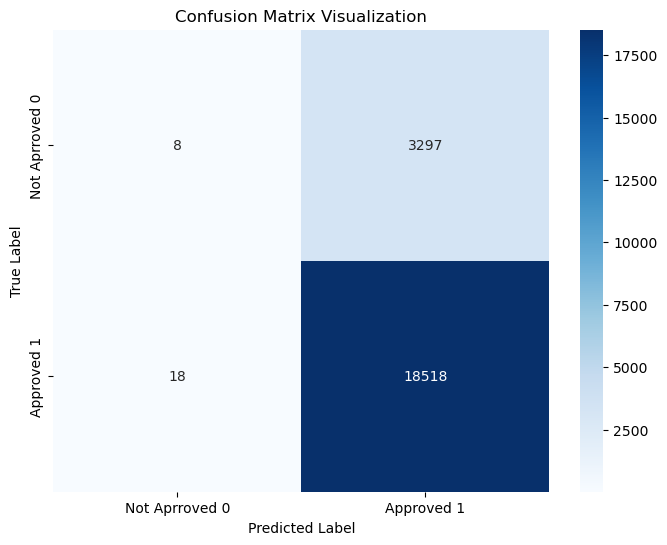

In [101]:
import seaborn as sns

cm = np.array([[8, 3297],
               [18, 18518]])

class_labels = ['Not Aprroved 0', 'Approved 1']

df_cm = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(8, 6))

sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix Visualization')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()


#### Model Performance Insights
- **Overall Correct Predictions:** The model was correct for 8 + 18,518 = 18,526 instances.
- **Overall Incorrect Predictions:** The model was incorrect for 3,297 + 18 = 3,315 instances.
- **Strong Performance in Positive Class:** The model is quite good at identifying the positive class, with a high number of True Positives (18,518) and a very low number of False Negatives (18).
- **Weak Performance in Negative Class:** The model struggles with the negative class, as it incorrectly classifies a large number of actual negative cases as positive (3,297 False Positives).

In [102]:
# Precision, recall, and F1 Score

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.00      0.00      3305
           1       0.85      1.00      0.92     18536

    accuracy                           0.85     21841
   macro avg       0.58      0.50      0.46     21841
weighted avg       0.77      0.85      0.78     21841



#### Precision, Recall, and F1 Score Interpretation
As stated earlier, that model is hihgly imbalanced which shows in the classification report. The model is essentially predicting Approved (1) for everything and ignoring Not Approved (0). 
- **Accuracy:** 0.85 accuracy rate is deceivingly high. This is just a reflectiong of the imbalance in the dataset.
- **Precision:** When the model predicts Approved (1), it's right about 85% of the time.
- **Recall:** The model failed to identify the Not Approved (0) instances.

The model is not learning the patterns for Not Approved (0). It's just playing the odds by simply predicting Approved (1) for every iteration and ignoring the Not Approved (0) samples. 

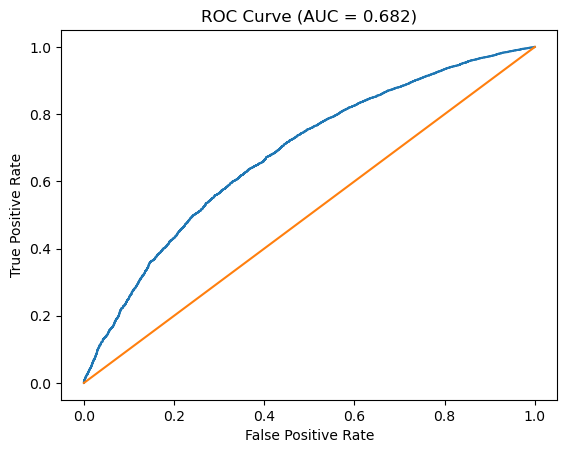

0.6818815999874636

In [103]:
# Roc and AUC Curves

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

auc

#### ROC Curve Interpretation

At 0.682, the model performs modestly better than a coin toss. It's able to slightly distinguish between the positive and negative classes but it's still not a highly effective predictor of our target variable. 

In [104]:
# Coefficient table

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
2,log_quantity,2.167600
1,log_price,1.871779
9,essay_word_count,0.024810
8,title_word_count,0.017621
3,teacher_number_of_previously_posted_projects,0.009827
5,title_length,0.000177
7,summary_length,-0.001777
6,essay_length,-0.002076
4,is_new_teacher,-0.091097
0,log_total_cost,-2.280737


#### Coeffecient Table Interpretation
- **Total project cost** can hurt a project's approval chances. The higher the project cost, the less likely the project will get approved.
- **Quantity and Price:** Higher quantity and individual price increases the odds of a project getting approved.

Essay word count, title word count teacher's experience, and title length all have little to no effect on the outcome.


In [115]:
# Improving model performance by adding categorical features 
# Convert categories to numbers using one-hot encoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = features

categorical_features = [
    "teacher_prefix",
    "school_state",
    "project_grade_category",
    "project_subject_categories",
    "project_subject_subcategories",
    "teacher_experience_bucket"
]

X2 = df[numeric_features + categorical_features].copy()
y2 = df["project_is_approved"].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=5000,
        n_jobs=-1,
        class_weight="balanced"  
    ))
])

model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)
y2_prob = model2.predict_proba(X2_test)[:, 1]

print("Accuracy:", accuracy_score(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))
print("AUC:", roc_auc_score(y2_test, y2_prob))

Accuracy: 0.6238267478595303
              precision    recall  f1-score   support

           0       0.23      0.65      0.34      3305
           1       0.91      0.62      0.74     18536

    accuracy                           0.62     21841
   macro avg       0.57      0.64      0.54     21841
weighted avg       0.81      0.62      0.68     21841

AUC: 0.6865212365094673


#### Even though the model showed high accuracy, a closer look revealed that the results were affected by class imbalance. Once again, the model performed very well at predicting approved projects but struggled to correctly identify projects that were not approved. This suggests that the model is still biased toward predicting approvals, since they make up most of the dataset. To correct this, class weighting will be applied to help the model better learn patterns associated with not-approved projects.

In [116]:
# Class weighting. Increasing the importance of Not Approved projects

LogisticRegression(class_weight="balanced")


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [117]:
model2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1
    ))
])


In [118]:
# Updating the model

model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)
y2_prob = model2.predict_proba(X2_test)[:, 1]

print("Accuracy:", accuracy_score(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))
print("AUC:", roc_auc_score(y2_test, y2_prob))

Accuracy: 0.6238267478595303
              precision    recall  f1-score   support

           0       0.23      0.65      0.34      3305
           1       0.91      0.62      0.74     18536

    accuracy                           0.62     21841
   macro avg       0.57      0.64      0.54     21841
weighted avg       0.81      0.62      0.68     21841

AUC: 0.6865209753339292


#### Final Model Interpretation
After applying class weighting, overall accuracy decreased, but the model’s ability to detect not-approved projects improved substantially. The classifier now identifies a majority of rejected projects, representing a significant improvement over the baseline model, which largely failed to detect rejections. This tradeoff reflects a more balanced and practically useful model.